# Notebook 6: Model Evaluation

Objectives:

- Evaluate the best model
- Generate visual reports
- Save artifacts for MLflow and documentation

### Imports

In [16]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

sns.set_style("whitegrid")

### Create Folder

In [17]:
os.makedirs("artifacts/evaluation", exist_ok=True)

### Load Model

In [18]:
model = joblib.load("models/best_model.pkl")

###  Load Test Data

In [19]:
X_test = joblib.load(
    "artifacts/preprocessing/X_test_processed.pkl"
)

y_test = joblib.load(
    "artifacts/preprocessing/y_test.pkl"
)

### Predictions

In [20]:
predictions = model.predict(X_test)

probabilities = model.predict_proba(X_test)[:,1]

C:\Users\Samsung\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Samsung\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


###  Confusion Matrix

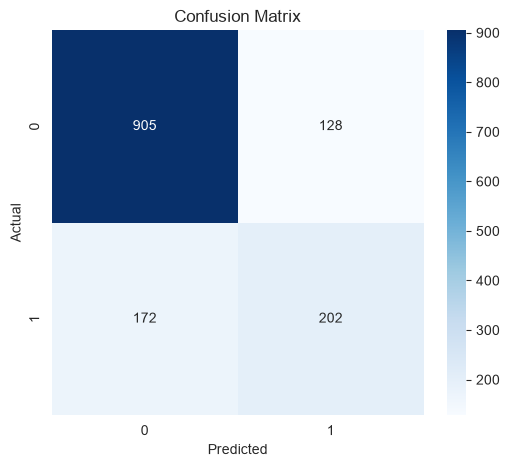

In [21]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(
    "artifacts/evaluation/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

###  Classification Report

In [22]:
report = classification_report(
    y_test,
    predictions
)

print(report)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.54      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



### ROC Curve

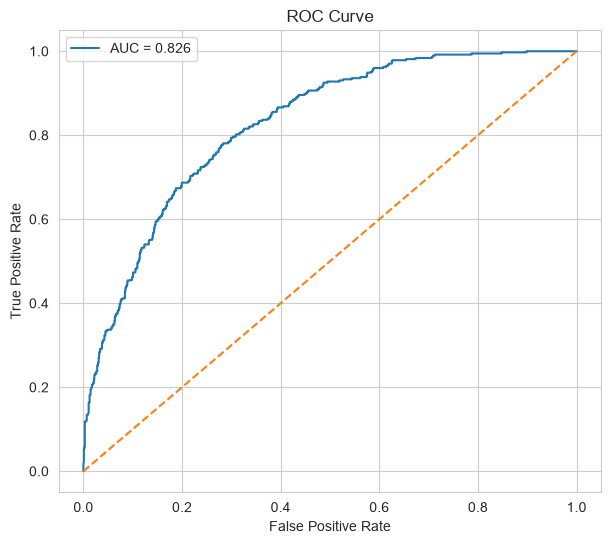

In [23]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

roc_auc = roc_auc_score(
    y_test,
    probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.savefig(
    "artifacts/evaluation/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

### Precision Recall Curve

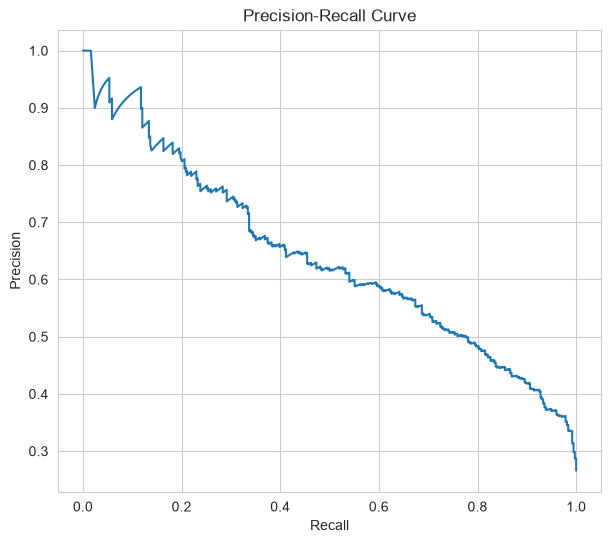

In [24]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.savefig(
    "artifacts/evaluation/precision_recall_curve.png",
    bbox_inches="tight"
)

plt.show()

### Feature Importance
This works especially well if LightGBM or XGBoost is your best model.

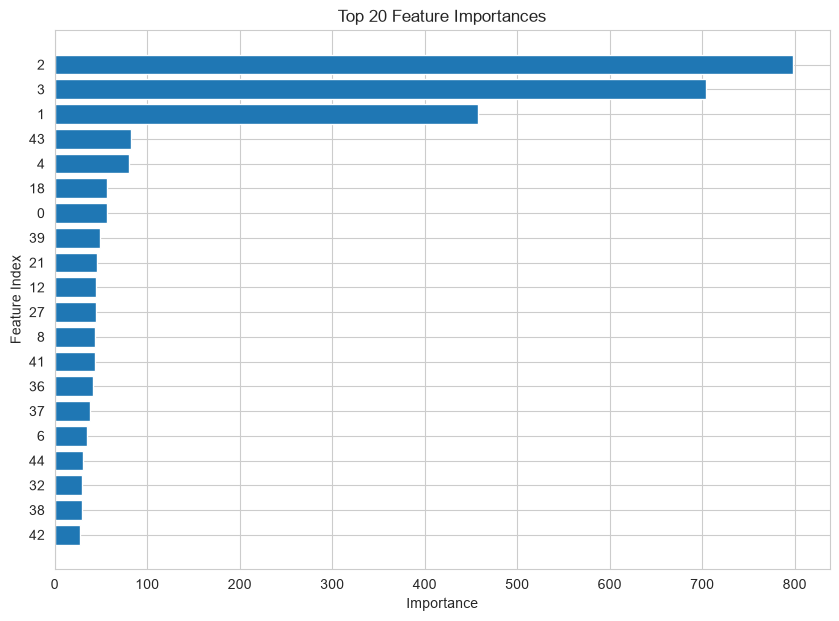

In [25]:
# Feature Importance

if hasattr(model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature_Index": range(len(model.feature_importances_)),
        "Importance": model.feature_importances_
    })

    importance_df = (
        importance_df
        .sort_values("Importance", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10,7))

    plt.barh(
        importance_df["Feature_Index"].astype(str),
        importance_df["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Importance")
    plt.ylabel("Feature Index")
    plt.title("Top 20 Feature Importances")

    plt.savefig(
        "artifacts/evaluation/feature_importance.png",
        bbox_inches="tight"
    )

    plt.show()

else:
    print("Selected model does not support feature importance.")

### Save Classification Report

In [26]:
with open(
    "artifacts/evaluation/classification_report.txt",
    "w"
) as file:

    file.write(report)

### Completion

In [27]:
print("Notebook 6 completed successfully.")

Notebook 6 completed successfully.
